# Belgian real Estate Data Analysis

## Setup

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib .pyplot as plt

print("All libraries are downloaded")

All libraries are downloaded


## Load Data

In [72]:
# Read the csv and print the head
df = pd.read_csv("../data/cleaned/properties_final.csv")
print(f"Data Loaded:{df.shape[0]} rows, {df.shape[1]} columns")

Data Loaded:12622 rows, 35 columns


## Class definition

In [73]:
class RealEstateAnalyzer:
    def __init__(self, df):
        self.df=df.copy()
        self.df['price_per_m2']=self.df['price']/self.df['living_area_m2']

        #Splitting the regions
        self.flanders = self.df[self.df['region'] == 'Flanders']
        self.wallonia = self.df[self.df['region'] == 'Wallonia']
        self.brussels = self.df[self.df['region'] == 'Brussels']

        print("Analyzer ok")


    def calculate_city_stats(self,region_df):
            stats = region_df.groupby('city').agg(
                avg_price = ('price', 'mean'),
                median_price = ('price','median'),
                avg_price_per_m2 = ('price_per_m2','mean'),
                count = ('price','count')
                ).reset_index()
            return stats[stats['count']>=5] 
    
    
    def plot_correlation_heatmap(self):
     numeric_columns = ['price','living_area_m2','bedrooms','bathrooms', 
                         'facades', 'has_garden',  'has_terrace', 
                        'is_nearby_city_prestigious']
        
     df_corr = df[numeric_columns].dropna(subset = ['price'])

     plt.figure(figsize=(8,6))  #size of the chart
     sns.heatmap(
        df_corr.corr()[['price']],
        annot = True,        # show the number inside the boxes
        fmt = '.2f',         # round to 2 decimal places
        cmap = 'coolwarm',   # red for positive and blue for negative
        vmin = -1,           # goes from -1 to 1
        vmax = 1
     )
     plt.title("Correlation of the Property Features with Price")
     plt.tight_layout()
     plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
     plt.show


    def plot_municipality_prices(self):
        city_stats = self.calculate_city_stats(self.df)

        fig, axes = plt.subplots(1, 2, figsize=(18, 9))

        # Most expensive in Belgium
        city_stats.nlargest(5, 'avg_price').plot(
        kind='bar', x='city', y='avg_price', 
        ax=axes[0], color='orange', legend=False , 
        )
        axes[0].set_title('Top 5 Most Expensive Municipalities', fontweight="bold")
        axes[0].set_xlabel('City', fontweight="bold")
        axes[0].set_ylabel('Average Price (€)', fontweight="bold")
        axes[0].tick_params(axis='x', rotation=45)

        # Least expensive in Belgium
        city_stats.nsmallest(5, 'avg_price').plot(
        kind='bar', x='city', y='avg_price', 
        ax=axes[1], color='skyblue', legend=False , 
        )
        axes[1].set_title('Top 5 Least Expensive Municipalities',fontweight="bold")
        axes[1].set_xlabel('City', fontweight="bold")
        axes[1].set_ylabel('Average Price (€)', fontweight="bold")
        axes[1].tick_params(axis='x', rotation=45)

        axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
)
        axes[1].yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
        )
        plt.suptitle('Most vs Least Expensive Municipalities in Belgium',fontsize = 16,fontweight="bold")
        fig.subplots_adjust(top=0.88, wspace=0.3)
        plt.savefig('../images/municipality_prices.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        
    def plot_by_region_avg(self):
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        
        regions = [
            ('Brussels', self.calculate_city_stats(self.brussels)),
            ('Flanders', self.calculate_city_stats(self.flanders)),
            ('Wallonia', self.calculate_city_stats(self.wallonia))
        ]
        
        for i, (region_name, stats) in enumerate(regions):
            # Most expensive
            stats.nlargest(5, 'avg_price').plot(
                kind='bar', x='city', y='avg_price',
                ax=axes[i][0], color='tomato', legend=False
            )
            axes[i][0].set_title(f'Most Expensive in {region_name}', fontsize=15, fontweight='bold')
            axes[i][0].set_xlabel('City', fontweight='bold')
            axes[i][0].set_ylabel('Average Price (€)', fontweight='bold')
            axes[i][0].tick_params(axis='x', rotation=45)
            axes[i][0].yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
            )

            # Least expensive
            stats.nsmallest(5, 'avg_price').plot(
                kind='bar', x='city', y='avg_price',
                ax=axes[i][1], color='steelblue', legend=False
            )
            axes[i][1].set_title(f'Least Expensive in {region_name}', fontsize=15, fontweight='bold')
            axes[i][1].set_xlabel('City', fontweight='bold')
            axes[i][1].set_ylabel('Average Price (€)', fontweight='bold')
            axes[i][1].tick_params(axis='x', rotation=45)
            axes[i][1].yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
            )


        plt.suptitle('Most vs Least Expensive Municipalities by Region', fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
        plt.subplots_adjust(hspace=0.6, wspace=0.3)
        plt.savefig('../images/municipality_prices_by_region.png', dpi=150, bbox_inches='tight')
        plt.show()


    def plot_by_region_median(self):
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        
        regions = [
            ('Brussels', self.calculate_city_stats(self.brussels)),
            ('Flanders', self.calculate_city_stats(self.flanders)),
            ('Wallonia', self.calculate_city_stats(self.wallonia))
        ]
        
        for i, (region_name, stats) in enumerate(regions):
            # Most expensive
            stats.nlargest(5, 'median_price').plot(
                kind='bar', x='city', y='median_price',
                ax=axes[i][0], color='tomato', legend=False
            )
            axes[i][0].set_title(f'Most Expensive in {region_name} (Median)', fontsize=15, fontweight='bold')
            axes[i][0].set_xlabel('City', fontweight='bold')
            axes[i][0].set_ylabel('Median Price (€)', fontweight='bold')
            axes[i][0].tick_params(axis='x', rotation=45)
            axes[i][0].yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
            )

            # Least expensive
            stats.nsmallest(5, 'median_price').plot(
                kind='bar', x='city', y='median_price',
                ax=axes[i][1], color='steelblue', legend=False
            )
            axes[i][1].set_title(f'Least Expensive in {region_name} (Median)', fontsize=15, fontweight='bold')
            axes[i][1].set_xlabel('City', fontweight='bold')
            axes[i][1].set_ylabel('Median Price (€)', fontweight='bold')
            axes[i][1].tick_params(axis='x', rotation=45)
            axes[i][1].yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
            )

        plt.suptitle('Most vs Least Expensive Municipalities by Median Price', fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
        plt.subplots_adjust(hspace=0.6, wspace=0.3)
        plt.savefig('../images/municipality_median_by_region.png', dpi=150, bbox_inches='tight')
        plt.show()   
     
    
    def plot_by_region_per_m2(self):
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        
        regions = [
            ('Brussels', self.calculate_city_stats(self.brussels)),
            ('Flanders', self.calculate_city_stats(self.flanders)),
            ('Wallonia', self.calculate_city_stats(self.wallonia))
        ]
        
        for i, (region_name, stats) in enumerate(regions):
            # Most expensive
            stats.nlargest(5, 'avg_price_per_m2').plot(
                kind='bar', x='city', y='avg_price_per_m2',
                ax=axes[i][0], color='tomato', legend=False
            )
            axes[i][0].set_title(f'Most Expensive in {region_name} (Price/m²)', fontsize=15, fontweight='bold')
            axes[i][0].set_xlabel('City', fontweight='bold')
            axes[i][0].set_ylabel('Avg Price per m² (€)', fontweight='bold')
            axes[i][0].tick_params(axis='x', rotation=45)
            axes[i][0].yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
            )

            # Least expensive
            stats.nsmallest(5, 'avg_price_per_m2').plot(
                kind='bar', x='city', y='avg_price_per_m2',
                ax=axes[i][1], color='steelblue', legend=False
            )
            axes[i][1].set_title(f'Least Expensive in {region_name} (Price/m²)', fontsize=15, fontweight='bold')
            axes[i][1].set_xlabel('City', fontweight='bold')
            axes[i][1].set_ylabel('Avg Price per m² (€)', fontweight='bold')
            axes[i][1].tick_params(axis='x', rotation=45)
            axes[i][1].yaxis.set_major_formatter(
                plt.FuncFormatter(lambda x, p: f'€{x:,.0f}')
            )

            

        plt.suptitle('Most vs Least Expensive Municipalities by Avg Price per m²', fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96], pad=2.0)
        plt.savefig('../images/municipality_per_m2_by_region.png', dpi=150, bbox_inches='tight')
        plt.show()
         
   

       

In [74]:
# creating the object
analyzer = RealEstateAnalyzer(df)

# Computing city stats per region
flanders_stats = analyzer.calculate_city_stats(analyzer.flanders)
wallonia_stats = analyzer.calculate_city_stats(analyzer.wallonia)
brussels_stats = analyzer.calculate_city_stats(analyzer.brussels)
city_stats = analyzer.calculate_city_stats(analyzer.df)

print ("City stats done")

Analyzer ok
City stats done


## Feature Correlation with Price

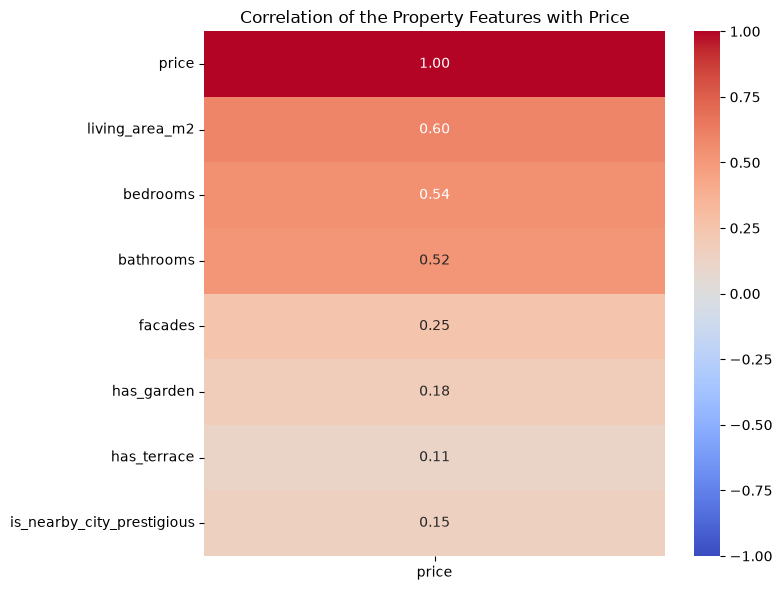

In [75]:
analyzer.plot_correlation_heatmap()

## Insights — Feature Correlation with Price

The heatmap reveals the following correlations with price:

- **Living area (m²)** is the strongest predictor of price (0.60) — 
  larger properties cost more, as expected.
- **Bedrooms (0.54) and bathrooms (0.52)** follow closely — 
  more rooms generally means a higher price.
- **Facades (0.25)** has a moderate correlation — 
  detached properties with more facades appears to be pricier.
- **Garden, terrace, and nearby prestigious city** have weak but 
  positive correlations — they add value but are not primary drivers.
- **has_garage was excluded** as it had too many missing values 
  to produce a meaningful correlation.
- Price is primarily driven by functional space (size + rooms), not cosmetic features like gardens or terraces

For the investor:
 Should focus on m² and location, not cosmetic features
  

## Municipality Prices

In [ ]:
analyzer.plot_municipality_prices()
analyzer.plot_by_region_avg()
analyzer.plot_by_region_median()
analyzer.plot_by_region_per_m2()


**Belgium overall:**
- Most expensive: Kraainem, Sterrebeek, Knokke-Heist — 
  Prestigious Brussels suburbs dominate.
- Least expensive: Blaimont, Baileux — small rural Wallonian villages with very limited market activity

**By Region:**
- **Flanders** most expensive cities are concentrated around Brussels periphery,cheapest are West Flemish Towns
- **Wallonia** Grez-Doiceau and Seneffe are  
  expensive — both are semi-rural towns close to Brussels/Charleroi 
  with large property sizes inflating the average.In accordance to all the regions, Wallonia has the lowest prices overall, with rural areas 
  being significantly cheaper.
- **Brussels** shows the least variation — it is consistently 
  expensive across all municipalities.Even the cheapest Brussels commune is more expensive than most Wallonian cities

  **Key Insights**
- Flanders - This highlights a strong “distance-to-Brussels” price gradient-The farther you move away from Brussels, the cheaper property prices tend to become.
- Wallonia - This suggests potential for value investing, but prices are low because fewer buyers are active in these areas
- Brussels functions as a stable and mature market.

**Average vs Median vs Price/m²:**
- Median price is more reliable than average as it is less 
  affected by luxury outliers.
- Price/m² tells a different story — smaller expensive apartments 
  in Brussels rank higher than large villas elsewhere.
- Brussels ranks higher in €/m² due to smaller, high-demand apartments
Rural areas may appear expensive in total price, but are often cheaper per m² due to larger property sizes  

**Key Insight**
Urban areas (Brussels) → high €/m², stable demand
Suburban/Flemish areas → high total prices, strong purchasing power
Wallonia → low prices, larger properties, weaker demand
 
**Bottom line:** Where you buy matters more than what you buy. 